# GEOM-Drugs Dataset Exploration and Visualization

This notebook demonstrates how to load, explore, and visualize the preprocessed GEOM-Drugs dataset. The GEOM-Drugs dataset contains 3D conformers for over 304,000 drug-like molecules, containing a rich diversity of organic elements (H, B, C, N, O, F, Al, Si, P, S, Cl, As, Se, Br, I). 

In this exploration, we:
1. Load the preprocessed PyTorch Geometric (PyG) dataset splits.
2. Inspect the structure of the PyG `Data` objects containing node features ($h$), 3D positions ($pos$), molecular SMILES, and MACCS key fingerprints ($maccs$).
3. Analyze element distributions and molecule size stats.
4. Visualize conformer coordinates in 3D.
5. Render an interactive, paginated, and searchable HTML grid of molecules using `mols2grid`.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
  
# Append root directory to sys.path so we can import g3m modules
sys.path.append(str(Path(os.getcwd()).parent))

from rdkit import Chem
from rdkit.Chem import MACCSkeys
import mols2grid

## 1. Load Preprocessed GEOM-Drugs Dataset
Let's load the training partition if it is already preprocessed. If not, we will check the preprocessed directory.

In [2]:
data_path = Path("../data/geom_drugs/preprocessed/train.pt")
if data_path.exists():
    print(f"Loading dataset from {data_path}...")
    train_data = torch.load(data_path)
    print(f"Loaded {len(train_data)} molecules successfully!")
else:
    print(f"Preprocessed dataset file not found at {data_path}.")
    print("Please run: python scripts/preprocess_geomdrugs.py to generate it first.")

Loading dataset from ../data/geom_drugs/preprocessed/train.pt...
Loaded 93287 molecules successfully!


## 2. Inspect PyG Data Object Structure
Let's check the structure of a single molecule's PyG `Data` object.

In [3]:
if 'train_data' in locals():
    mol_data = train_data[0]
    print("Structure of a single PyG Data object:")
    print(mol_data)
    print("\nAttributes:")
    print(f"- Node features (h, atomic numbers): {mol_data.h.shape} -> {mol_data.h}")
    print(f"- Coordinates (pos): {mol_data.pos.shape}")
    print(f"- Molecular SMILES: '{mol_data.smiles}'")
    print(f"- MACCS Key Fingerprint (maccs): {mol_data.maccs.shape} -> {mol_data.maccs.tolist()[:20]}...")

Structure of a single PyG Data object:
Data(pos=[33, 3], h=[33], maccs=[167], smiles='O=C([O-])CN(CCN(CC(=O)[O-])CC(=O)O)CC(=O)[O-]', eigenvalues=[3], eigenvalues_normalized=[3], eigenvalues_normalized_no_h=[3])

Attributes:
- Node features (h, atomic numbers): torch.Size([33]) -> tensor([8, 6, 8, 6, 7, 6, 1, 6, 7, 6, 1, 1, 6, 8, 8, 6, 6, 8, 8, 1, 1, 1, 1, 1,
        1, 6, 1, 1, 6, 8, 8, 1, 1])
- Coordinates (pos): torch.Size([33, 3])
- Molecular SMILES: 'O=C([O-])CN(CCN(CC(=O)[O-])CC(=O)O)CC(=O)[O-]'
- MACCS Key Fingerprint (maccs): torch.Size([167]) -> [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...


## 3. Dataset Statistics (Atom cutoffs and Molecule Sizes)
Let's visualize the distribution of molecule sizes (number of atoms including hydrogens) in our filtered dataset.

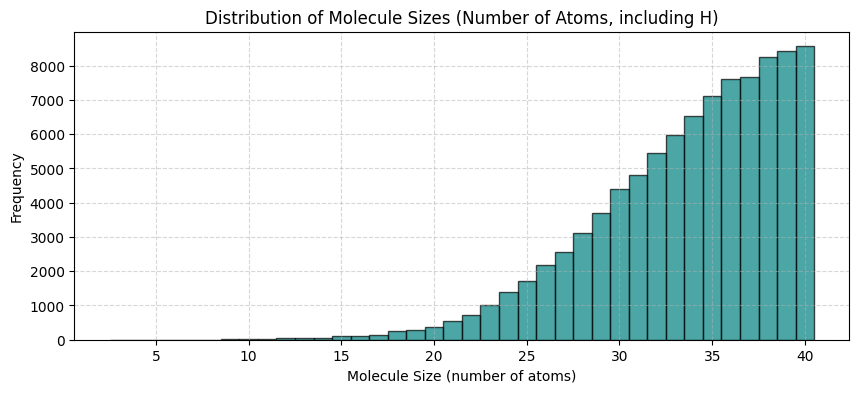

Total Molecules in Training Split: 93287
Min size: 3 atoms
Max size: 40 atoms (matching the cutoff of 40)
Average size: 33.67 atoms


In [4]:
if 'train_data' in locals():
    sizes = [data.h.shape[0] for data in train_data]
    
    plt.figure(figsize=(10, 4))
    plt.hist(sizes, bins=range(min(sizes), max(sizes) + 2), color='teal', edgecolor='black', alpha=0.7, align='left')
    plt.title("Distribution of Molecule Sizes (Number of Atoms, including H)")
    plt.xlabel("Molecule Size (number of atoms)")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    print(f"Total Molecules in Training Split: {len(train_data)}")
    print(f"Min size: {min(sizes)} atoms")
    print(f"Max size: {max(sizes)} atoms (matching the cutoff of 40)")
    print(f"Average size: {np.mean(sizes):.2f} atoms")

### Molecule Size Distribution Excluding Hydrogens

Let's also inspect the distribution of molecule sizes when excluding hydrogen atoms (heavy atoms only).

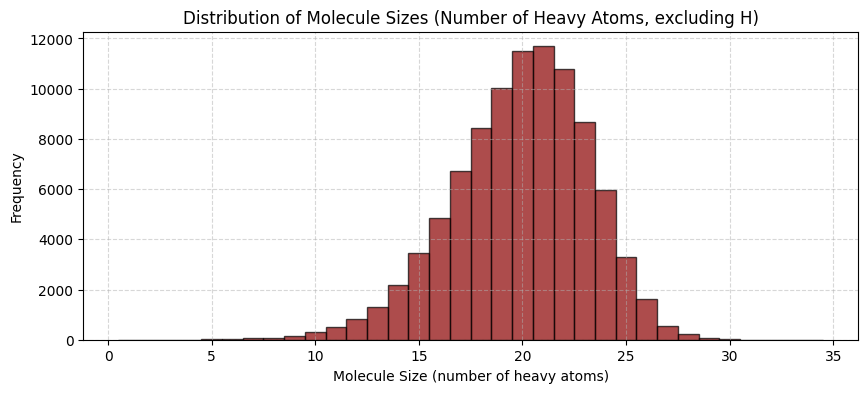

Total Molecules in Training Split: 93287
Min size (no H): 1 atoms
Max size (no H): 34 atoms
Average size (no H): 19.90 atoms


In [5]:
if 'train_data' in locals():
    sizes_no_h = [torch.sum(data.h != 1).item() for data in train_data]
    
    plt.figure(figsize=(10, 4))
    plt.hist(sizes_no_h, bins=range(min(sizes_no_h), max(sizes_no_h) + 2), color='darkred', edgecolor='black', alpha=0.7, align='left')
    plt.title("Distribution of Molecule Sizes (Number of Heavy Atoms, excluding H)")
    plt.xlabel("Molecule Size (number of heavy atoms)")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    print(f"Total Molecules in Training Split: {len(train_data)}")
    print(f"Min size (no H): {min(sizes_no_h)} atoms")
    print(f"Max size (no H): {max(sizes_no_h)} atoms")
    print(f"Average size (no H): {np.mean(sizes_no_h):.2f} atoms")

## 4. Conformer Coordinate Visualisation in 3D
Let's plot the 3D conformer coordinates of one of the molecules to check that it is properly centered around $(0, 0, 0)$.

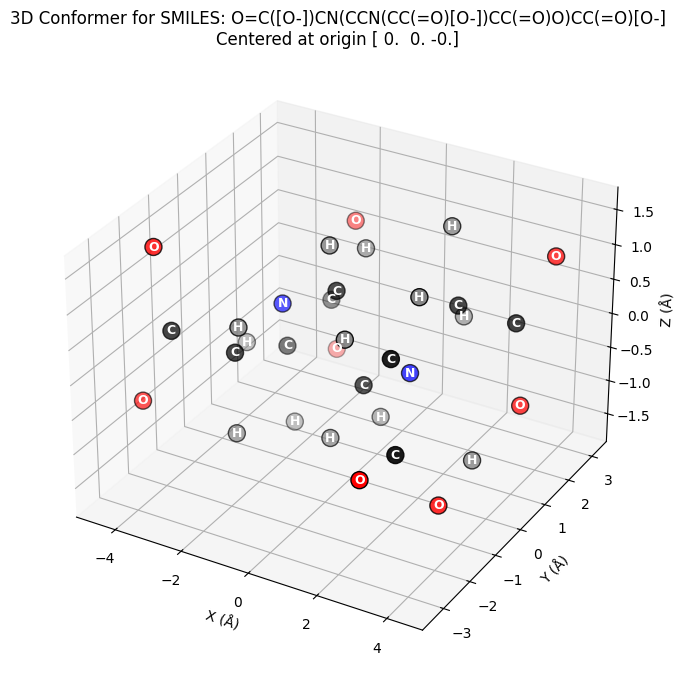

In [6]:
if 'train_data' in locals():
    mol_data = train_data[0]
    pos = mol_data.pos.numpy()
    h = mol_data.h.numpy()
    
    # Map atomic numbers to colors
    # 1: H (gray), 6: C (black), 7: N (blue), 8: O (red), 9: F (green), 16: S (yellow), 17: Cl (dark green)
    color_map = {1: 'gray', 6: 'black', 7: 'blue', 8: 'red', 9: 'green', 15: 'orange', 16: 'yellow', 17: 'darkgreen', 35: 'brown', 53: 'purple'}
    colors = [color_map.get(atomic_num, 'magenta') for atomic_num in h]
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot atoms
    ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], c=colors, s=150, edgecolors='black', depthshade=True)
    
    # Add text labels for atoms
    atom_symbols = {1: 'H', 6: 'C', 7: 'N', 8: 'O', 9: 'F', 15: 'P', 16: 'S', 17: 'Cl', 35: 'Br', 53: 'I'}
    for i, p in enumerate(pos):
        symbol = atom_symbols.get(int(h[i]), str(h[i]))
        ax.text(p[0], p[1], p[2], symbol, color='white', ha='center', va='center', fontsize=9, weight='bold')
        
    ax.set_title(f"3D Conformer for SMILES: {mol_data.smiles}\nCentered at origin {pos.mean(axis=0).round(4)}")
    ax.set_xlabel("X (Å)")
    ax.set_ylabel("Y (Å)")
    ax.set_zlabel("Z (Å)")
    
    plt.show()

## 5. Interactive paginated grid visualization with `mols2grid`
Using the SMILES and MACCS key molecular descriptions, we build a Pandas DataFrame and display it in an interactive, searchable grid.

In [7]:
if 'train_data' in locals():
    # Convert a subset of molecules to a Pandas DataFrame for mols2grid
    subset_size = min(100, len(train_data))
    
    mol_records = []
    for i in range(subset_size):
        data = train_data[i]
        maccs_str = "".join(map(str, data.maccs.tolist()))
        mol_records.append({
            "SMILES": data.smiles,
            "Index": i,
            "Num Atoms": data.h.shape[0],
            "MACCS Key Signature": f"{maccs_str[:25]}..."
        })
        
    df_mols = pd.DataFrame(mol_records)
    
    # Render the interactive grid using mols2grid
    mols2grid.display(df_mols,
                      smiles_col="SMILES",
                      subset=["Index", "Num Atoms", "MACCS Key Signature"],
                      tooltip=["SMILES", "MACCS Key Signature"],
                      size=(160, 160),
                      limit=12)